In [1]:
from IPython.display import display, HTML
display(HTML("<h2>Agentic AI System</h2> \n " \
"<h3> Simple AI ChatBot"))

In [2]:
from typing import Annotated, List
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


In [3]:
class State(TypedDict):

    messages: Annotated[List, add_messages]




In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DE5A4CE3C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DE5A4CEE40>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
# llm = init_chat_model("groq: llama3-8b-8192")
# llm

In [7]:
def ChatBot(state : State):

    return {
        "messages" : [llm.invoke(state["messages"])]
    }

In [8]:
graph_builder = StateGraph(State)

graph_builder.add_node("LLMChatNode", ChatBot)

graph_builder.add_edge(START, "LLMChatNode")
graph_builder.add_edge("LLMChatNode", END)

graph= graph_builder.compile()


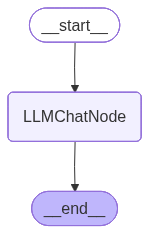

In [9]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [10]:
result = graph.invoke({"messages": "Hi, How Can I Assist You?"})

for msg in result["messages"]:
    msg.pretty_print()



================================ Human Message =================================

Hi, How Can I Assist You?
================================== Ai Message ==================================

I'm a large language model, I'm here to assist you with any questions or topics you'd like to discuss. I can provide information, answer questions, generate text, and even engage in conversation.

If you're looking for assistance, you can ask me anything on a wide range of subjects, such as:

- General knowledge
- History
- Science and technology
- Health and wellness
- Culture and entertainment
- Language learning
- Writing and editing
- And more!

Or, if you'd like to engage in a conversation, I can chat with you about your interests, hobbies, or daily life.

What would you like to do today?


In [11]:
result["messages"]

[HumanMessage(content='Hi, How Can I Assist You?', additional_kwargs={}, response_metadata={}, id='cad05939-9f90-464a-8458-08b48629c202'),
 AIMessage(content="I'm a large language model, I'm here to assist you with any questions or topics you'd like to discuss. I can provide information, answer questions, generate text, and even engage in conversation.\n\nIf you're looking for assistance, you can ask me anything on a wide range of subjects, such as:\n\n- General knowledge\n- History\n- Science and technology\n- Health and wellness\n- Culture and entertainment\n- Language learning\n- Writing and editing\n- And more!\n\nOr, if you'd like to engage in a conversation, I can chat with you about your interests, hobbies, or daily life.\n\nWhat would you like to do today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 134, 'prompt_tokens': 43, 'total_tokens': 177, 'completion_time': 0.213910618, 'completion_tokens_details': None, 'prompt_time': 0.002060756, 'pr

In [12]:
result["messages"][-1].content

"I'm a large language model, I'm here to assist you with any questions or topics you'd like to discuss. I can provide information, answer questions, generate text, and even engage in conversation.\n\nIf you're looking for assistance, you can ask me anything on a wide range of subjects, such as:\n\n- General knowledge\n- History\n- Science and technology\n- Health and wellness\n- Culture and entertainment\n- Language learning\n- Writing and editing\n- And more!\n\nOr, if you'd like to engage in a conversation, I can chat with you about your interests, hobbies, or daily life.\n\nWhat would you like to do today?"

In [13]:
for event in graph.stream({"messages": "How Are You?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How can I assist you today?


## ChatBot with Tavily

In [14]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results =2)

tool.invoke("What is LangGraph?")


{'query': 'What is LangGraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the 

In [15]:
def multiPly(a:int, b:int)->int:
    """
    Multipy a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: Output int
    
    """
    return a*b

In [16]:
tools = [tool, multiPly]

In [17]:
llm_with_tool = llm.bind_tools(tools)


In [18]:
llm_with_tool


_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DE5A4CE3C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DE5A4CEE40>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when 

## State Graph

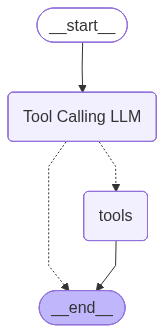

In [19]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode

builder = StateGraph(State)

def tool_calling_llm(state: State):
    return {
        "messages": [
            llm_with_tool.invoke(state["messages"])
        ]
    }

builder.add_node(
    "Tool Calling LLM",
    tool_calling_llm
)

builder.add_node(
    "tools",
    ToolNode(tools)
)

builder.add_edge(
    START,
    "Tool Calling LLM"
)

builder.add_conditional_edges(
    "Tool Calling LLM",
    tools_condition
)

builder.add_edge(
    "tools",
    END
)



graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
response = graph.invoke(
    {
        "messages": "What is FIFA News?"
    }
)

In [21]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is FIFA News?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (5z1g03df6)
 Call ID: 5z1g03df6
  Args:
    query: FIFA News
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "FIFA News", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.sportingnews.com/in/football/news/watch-portugal-chile-live-stream-tv-channel-start-time-fifa-world-cup-warm/e7aad40dc84659dba788227f", "title": "Where to watch Portugal vs. Chile live stream, TV channel, start time for FIFA World Cup warm-up match - sportingnews.com", "score": 1.0, "published_date": "Sat, 06 Jun 2026 17:32:19 GMT", "content": "# Where to watch Portugal vs. Chile live stream, TV channel, start time for FIFA World Cup warm-up match. Portugal will play a FIFA World Cup 2026 wa

In [22]:
response = graph.invoke(
    {
        "messages": "What is 2 Multipy by 5?"
    }
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 Multipy by 5?
================================== Ai Message ==================================
Tool Calls:
  multiPly (wc0vt9bfp)
 Call ID: wc0vt9bfp
  Args:
    a: 2
    b: 5
================================= Tool Message =================================
Name: multiPly

10


In [23]:
response = graph.invoke(
    {
        "messages": "What is 2 Multipy by 5 and then Muliply by 10?"
    }
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 Multipy by 5 and then Muliply by 10?
================================== Ai Message ==================================
Tool Calls:
  multiPly (qj1ajdbex)
 Call ID: qj1ajdbex
  Args:
    a: 2
    b: 5
  multiPly (atd9pqxrs)
 Call ID: atd9pqxrs
  Args:
    a: 10
    b: 25
================================= Tool Message =================================
Name: multiPly

10
================================= Tool Message =================================
Name: multiPly

250


In [24]:
response = graph.invoke(
    {
        "messages": "Give me Recent FIFA Portugal News and Then 8 Multiply by 9"
    }
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me Recent FIFA Portugal News and Then 8 Multiply by 9
================================== Ai Message ==================================
Tool Calls:
  tavily_search (bptmrpbeg)
 Call ID: bptmrpbeg
  Args:
    query: Recent FIFA Portugal News
    start_date: 2024-01-01
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Recent FIFA Portugal News", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://apnews.com/article/portugal-ronaldo-nations-league-fb7d8d9e8e76e0821f12eab82f4df0d2", "title": "Ronaldo included in Portugal’s first squad after scoreless Euro 2024 - The Associated Press", "score": 0.5408517, "published_date": "Fri, 30 Aug 2024 09:53:00 GMT", "content": "Ronaldo included in Portugal's first squad after scoreless Euro 2024 | AP News AP & Elections AP & Elections More From AP News L

# ReAct Agent Architecture

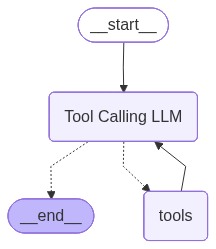

In [25]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import SystemMessage

system_prompt = """
You are a helpful AI assistant.

Always:
1. Use tools when needed.
2. After receiving tool results, summarize ALL tool outputs clearly.
3. Never ignore any tool result.
"""



def tool_calling_llm(state: State):

    messages = [
        SystemMessage(content=system_prompt)
    ] + state["messages"]

    return {
        "messages": [
            llm_with_tool.invoke(messages)
        ]
    }


builder = StateGraph(State)
builder.add_node(
    "Tool Calling LLM",
    tool_calling_llm
)

builder.add_node(
    "tools",
    ToolNode(tools)
)

builder.add_edge(
    START,
    "Tool Calling LLM"
)

builder.add_conditional_edges(
    "Tool Calling LLM",
    tools_condition
)

builder.add_edge(
    "tools",
    "Tool Calling LLM"
)



graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
response = graph.invoke(
    {
        "messages": "Give me Recent FIFA News and Then 8 Multiply by 9"
    }
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me Recent FIFA News and Then 8 Multiply by 9
================================== Ai Message ==================================
Tool Calls:
  tavily_search (9cketfjrp)
 Call ID: 9cketfjrp
  Args:
    query: Recent FIFA News
    search_depth: advanced
    topic: news
  multiPly (9g0n859yh)
 Call ID: 9g0n859yh
  Args:
    a: 8
    b: 9
================================= Tool Message =================================
Name: tavily_search

{"query": "Recent FIFA News", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.greenwichtime.com/sports/article/fifa-and-the-fifpro-union-agree-on-a-cooperation-22300282.php", "title": "FIFA and the FIFPRO union agree on a cooperation deal covering transfers and player welfare - Greenwich Time", "score": 0.54971373, "published_date": "Thu, 11 Jun 2026 01:04:27 GMT", "content": "Subscribe\n\nSports\n\n# FIFA and the FIFPRO union ag

In [28]:
final_response = response["messages"][-1].content

print(final_response)

Here is the summary of the tool outputs:

Tavily Search Output:
* The search query was "Recent FIFA News" with advanced search depth and news topic.
* The search results include an article from Greenwich Time about a cooperation agreement between FIFA and the FIFPRO union, and an article from Sky Sports about the latest news and updates from the World Cup.
* The results also include other articles and videos related to FIFA, the World Cup, and football.

Multiplication Output:
* The result of multiplying 8 and 9 is 72.


In [29]:
response = graph.invoke(
    {
        "messages": "Hello My Name is MoniRuL"
    }
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello My Name is MoniRuL
================================== Ai Message ==================================

Nice to meet you, MoniRuL. How can I assist you today? Do you have a question or need help with something?


# Adding Memory in AI Agent

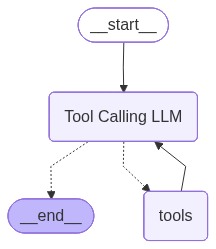

In [30]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import SystemMessage
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

system_prompt = """
You are a helpful AI assistant.

Always:
1. Use tools when needed.
2. After receiving tool results, summarize ALL tool outputs clearly.
3. Never ignore any tool result.
"""



def tool_calling_llm(state: State):

    messages = [
        SystemMessage(content=system_prompt)
    ] + state["messages"]

    return {
        "messages": [
            llm_with_tool.invoke(messages)
        ]
    }


builder = StateGraph(State)
builder.add_node(
    "Tool Calling LLM",
    tool_calling_llm
)

builder.add_node(
    "tools",
    ToolNode(tools)
)

builder.add_edge(
    START,
    "Tool Calling LLM"
)

builder.add_conditional_edges(
    "Tool Calling LLM",
    tools_condition
)

builder.add_edge(
    "tools",
    "Tool Calling LLM"
)



graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
config = {
    "configurable": {
        "thread_id": "1"
    }
}

response = graph.invoke(
    {
        "messages": "Hello My Name is MoniRuL"
    },
    config=config
)



print("++++++++++++++++++++++++++++++++++++++++++++++++")

for m in response["messages"]: m.pretty_print()

++++++++++++++++++++++++++++++++++++++++++++++++
================================ Human Message =================================

Hello My Name is MoniRuL
================================== Ai Message ==================================

Nice to meet you, MoniRuL! I'm here to help with any questions or tasks you may have. What's on your mind today?


In [32]:
config = {
    "configurable": {
        "thread_id": "1"
    }
}

response = graph.invoke(
    {
        "messages": "What is my name?"
    },
    config=config
)





for m in response["messages"]: m.pretty_print()

================================ Human Message =================================

Hello My Name is MoniRuL
================================== Ai Message ==================================

Nice to meet you, MoniRuL! I'm here to help with any questions or tasks you may have. What's on your mind today?
================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

MoniRuL


# Streaming

In [33]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [34]:
def superBot(state: State):
    return {
        "messages":[llm.invoke(state["messages"])]
    }

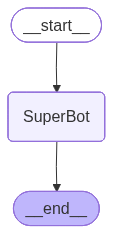

In [35]:
graph = StateGraph(State)

graph.add_node("SuperBot", superBot)
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer=memory)


from IPython.display import Image, display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [36]:
config = {
    "configurable": {
        "thread_id": "1"
    }
}

for chunk in graph_builder.stream({"messages": "Hi, My Name is Monirul and I Like AI and ML "}, config , stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Monirul. It's great to hear that you're interested in Artificial Intelligence (AI) and Machine Learning (ML). These are exciting and rapidly evolving fields that have the potential to transform many areas of our lives.\n\nWhat specifically about AI and ML interests you? Are you looking to learn more about the basics, or are you already familiar with some concepts and looking to dive deeper? Perhaps you're interested in exploring a particular application area, such as computer vision or natural language processing?\n\nAlso, what's your background and experience level in AI and ML? Are you a beginner, or do you have some experience with programming languages like Python, R, or TensorFlow?\n\nLet me know, and I'll be happy to help you get started or provide guidance on where to focus your learning efforts.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 164, 'prompt_tokens': 50, 'total_tokens':

In [37]:


for chunk in graph_builder.stream({"messages": "Hi, My Name is Monirul and I Like AI and ML "}, config , stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My Name is Monirul and I Like AI and ML ', additional_kwargs={}, response_metadata={}, id='01f7da2e-5e3c-42fb-ae46-998dafea55de'), AIMessage(content="Nice to meet you, Monirul. It's great to hear that you're interested in Artificial Intelligence (AI) and Machine Learning (ML). These are exciting and rapidly evolving fields that have the potential to transform many areas of our lives.\n\nWhat specifically about AI and ML interests you? Are you looking to learn more about the basics, or are you already familiar with some concepts and looking to dive deeper? Perhaps you're interested in exploring a particular application area, such as computer vision or natural language processing?\n\nAlso, what's your background and experience level in AI and ML? Are you a beginner, or do you have some experience with programming languages like Python, R, or TensorFlow?\n\nLet me know, and I'll be happy to help you get started or provide guidance on where to focus 

In [38]:
config = {
    "configurable": {
        "thread_id": "5"
    }
}

for chunk in graph_builder.stream({"messages": "Hi, My Name is Monirul and I Like AI and ML "}, config , stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Monirul. AI and ML (Artificial Intelligence and Machine Learning) are fascinating fields that have the potential to revolutionize many aspects of our lives. What specific areas of AI and ML interest you the most? Are you interested in:\n\n1. Natural Language Processing (NLP)?\n2. Computer Vision?\n3. Predictive Modeling?\n4. Reinforcement Learning?\n5. Something else?\n\nAlso, are you a student, researcher, or professional working with AI and ML? I'd be happy to chat and help you explore your interests.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 115, 'prompt_tokens': 50, 'total_tokens': 165, 'completion_time': 0.225142345, 'completion_tokens_details': None, 'prompt_time': 0.002431678, 'prompt_tokens_details': None, 'queue_time': 0.045850891, 'total_time': 0.227574023}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reaso

In [39]:
for chunk in graph_builder.stream({"messages": "I also Like Algorithms"}, config , stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My Name is Monirul and I Like AI and ML ', additional_kwargs={}, response_metadata={}, id='7efdf5f9-382f-497e-a27c-56723389dcf2'), AIMessage(content="Nice to meet you, Monirul. AI and ML (Artificial Intelligence and Machine Learning) are fascinating fields that have the potential to revolutionize many aspects of our lives. What specific areas of AI and ML interest you the most? Are you interested in:\n\n1. Natural Language Processing (NLP)?\n2. Computer Vision?\n3. Predictive Modeling?\n4. Reinforcement Learning?\n5. Something else?\n\nAlso, are you a student, researcher, or professional working with AI and ML? I'd be happy to chat and help you explore your interests.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 115, 'prompt_tokens': 50, 'total_tokens': 165, 'completion_time': 0.225142345, 'completion_tokens_details': None, 'prompt_time': 0.002431678, 'prompt_tokens_details': None, 'queue_time': 0.045850891, 'to

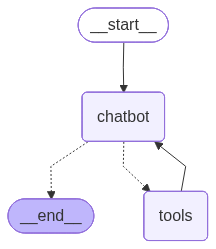

In [44]:
from typing import Annotated
from typing_extensions import TypedDict

from dotenv import load_dotenv
load_dotenv()

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import interrupt
from langgraph.checkpoint.memory import MemorySaver

# LLM
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)


class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

memory = MemorySaver()


@tool
def human_assistance(query: str) -> str:
    """Request assistance from human"""

    human_response = interrupt({"query": query})
    return human_response["data"]


search_tool = TavilySearch(max_results=2)

tools = [search_tool, human_assistance]

llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):

    response = llm_with_tools.invoke(state["messages"])

    return {
        "messages": [response]
    }


tool_node = ToolNode(tools)

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", tool_node)

graph_builder.add_edge(START, "chatbot")

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)

graph_builder.add_edge("tools", "chatbot")

graph = graph_builder.compile(
    checkpointer=memory
)

display(Image(graph.get_graph().draw_mermaid_png()))



In [41]:
from langchain_core.messages import HumanMessage

config = {
    "configurable": {
        "thread_id": "1"
    }
}

user_input ="What is AI?"

events = graph.stream(
    {
        "messages": user_input
    },
    config, 
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()





================================ Human Message =================================

What is AI?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (y1svmc01j)
 Call ID: y1svmc01j
  Args:
    query: What is AI
    search_depth: basic
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "What is AI", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.wikipedia.org/wiki/Artificial_intelligence", "title": "Artificial intelligence - Wikipedia", "content": "# Artificial intelligence. | Major goals  * Artificial general intelligence * Intelligent agent * Recursive self-improvement * Planning * Computer vision * General game playing * Knowledge representation * Natural language processing * Robotics * AI safety |. **Artificial intelligence** (**AI**) is the capability of computational systems to perform tasks typically ass

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch

from langchain_core.messages import (
    HumanMessage,
    SystemMessage
)

from langgraph.graph import (
    StateGraph,
    START,
    END
)

from langgraph.graph.message import add_messages

from langgraph.prebuilt import (
    ToolNode,
    tools_condition
)

from langgraph.checkpoint.memory import MemorySaver


# =========================================
# LLM
# =========================================

llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)


# =========================================
# STATE
# =========================================

class State(TypedDict):
    messages: Annotated[list, add_messages]


# =========================================
# GRAPH BUILDER
# =========================================

graph_builder = StateGraph(State)

memory = MemorySaver()


# =========================================
# TOOLS
# =========================================

search_tool = TavilySearch(max_results=2)

tools = [search_tool]


# =========================================
# BIND TOOLS
# =========================================

llm_with_tools = llm.bind_tools(tools)


# =========================================
# SYSTEM PROMPT
# =========================================

system_message = SystemMessage(
    content="""
You are a helpful AI assistant.

Rules:
1. Use tools only when needed.
2. After using tools, provide final answer.
3. Never call tools repeatedly.
4. Keep answers concise and clear.
"""
)


# =========================================
# CHATBOT NODE
# =========================================

def chatbot(state: State):

    messages = [system_message] + state["messages"]

    response = llm_with_tools.invoke(messages)

    return {
        "messages": [response]
    }


# =========================================
# TOOL NODE
# =========================================

tool_node = ToolNode(tools)


# =========================================
# ADD NODES
# =========================================

graph_builder.add_node("chatbot", chatbot)

graph_builder.add_node("tools", tool_node)


# =========================================
# GRAPH FLOW
# =========================================

graph_builder.add_edge(START, "chatbot")

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)

graph_builder.add_edge("tools", END)


# =========================================
# COMPILE GRAPH
# =========================================

graph = graph_builder.compile(
    checkpointer=memory
)


# =========================================
# CONFIG
# =========================================

config = {
    "configurable": {
        "thread_id": "1"
    },
    "recursion_limit": 5
}


# =========================================
# END TO END CHATBOT LOOP
# =========================================

print("\n🤖 AI Chatbot Started")
print("Type 'exit' to stop.\n")


while True:

    user_input = input("You: ")

    if user_input.lower() in ["exit", "quit"]:
        print("\n👋 Chatbot Stopped")
        break

    events = graph.stream(
        {
            "messages": [
                HumanMessage(content=user_input)
            ]
        },
        config,
        stream_mode="values"
    )

    print("\n🤖 Assistant:\n")

    for event in events:

        if "messages" in event:

            last_message = event["messages"][-1]

            last_message.pretty_print()

    print("\n" + "=" * 60 + "\n")


🤖 AI Chatbot Started
Type 'exit' to stop.


🤖 Assistant:

================================ Human Message =================================


================================== Ai Message ==================================

I'm happy to help you with your query. However, I don't see a specific question or topic you'd like me to search for. Could you please provide more details or clarify what you're looking for? I'll do my best to assist you.



🤖 Assistant:

================================ Human Message =================================


================================== Ai Message ==================================
Tool Calls:
  tavily_search (zysadfhtb)
 Call ID: zysadfhtb
  Args:
    end_date: 2024-12-31
    exclude_domains: []
    include_domains: []
    include_images: False
    query: current news
    search_depth: basic
    start_date: 2024-01-01
    time_range: month
    topic: news
================================= Tool Message =================================
Name: tavil